## Voronoi computation tests

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from controllers import *
from scipy import spatial

%matplotlib qt

# Generate points
points = np.random.rand(5,3)*2-1
print(points)

# Convex hull
# Each combination of 3 points is a triangle
max_area = 0
max_points = np.zeros((3,3))
for i in range(len(points)-2):
    for j in range(i+1,len(points)-1):
        for k in range(j+1,len(points)):
            # Compute aera of triangle
            v1 = points[j]-points[i]
            v2 = points[k]-points[i]
            area = np.linalg.norm(np.cross(v1,v2))/2
            if area>max_area:
                max_area = area
                max_points = np.array([points[i],points[j],points[k]])

print(f'Max area: {max_area} with points {max_points}')

# Volume of convex hull
hull = spatial.ConvexHull(points, incremental=True)
print(hull.volume)

# Visualize points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2],s=50)
plt.show()



[[-0.70124895  0.86388669 -0.63792337]
 [-0.52951495  0.6985171  -0.45567736]
 [ 0.14570243 -0.41637537 -0.75916066]
 [ 0.51791478  0.04133966 -0.20908202]
 [-0.47406441 -0.83231322  0.24440962]]
Max area: 1.0601277893976784 with points [[-0.70124895  0.86388669 -0.63792337]
 [ 0.51791478  0.04133966 -0.20908202]
 [-0.47406441 -0.83231322  0.24440962]]
0.27711034324859035


In [3]:
def find_combination(points, c):
    # Recursive loop
    if len(points) == c:
        yield points
    else:
        for i in range(len(points)):
            temp_points = points.copy()
            temp_points = np.delete(temp_points,i,axis=0)
            yield from find_combination(temp_points, c)


In [4]:
def combinations(n, k):
   result = []

   def backtrack(start, current_combination):
      if len(current_combination) == k:
         result.append(current_combination)
         return

      for i in range(start, n):
         backtrack(i+1, current_combination + [i])

   backtrack(0, [])
   return result

In [5]:
test = [1,2,3,4,5]
result=list(combinations(4,3))

print(result)

[[0, 1, 2], [0, 1, 3], [0, 2, 3], [1, 2, 3]]


In [6]:
points = np.array([[0,2],[-1,1], [2,2], [1,2.1]])
hull = spatial.ConvexHull(points, qhull_options='QG3')
print(hull.good)
# plt.figure()
# plt.plot(points[hull.vertices,0], points[hull.vertices,1], 'r--', lw=2)
# plt.scatter(points[:,0], points[:,1])
# plt.show()

[False False  True]


In [7]:
#pdcontrol = PdController(1, 0.1)

angle = np.pi/8
current_heading = np.array([np.cos(angle),np.sin(angle),0])
desired_heading = np.array([1,0,0])

control = pdcontrol.get_control_from_orientation(current_heading, desired_heading, 0.01)

print(control)

NameError: name 'pdcontrol' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d

%matplotlib qt
from helper_functions import scatter

MIN, MAX = -0.5,0.5
# Test for real size scatter dots
fig = plt.figure()
ax = fig.add_subplot(111)
data = np.array([[0,0,0]])
#ax.scatter(data[:,0], data[:,1], s=300)
#ax.add_patch(plt.Circle((0,0), 0.1, color='r', fill=True))
s = scatter(data[:,0], data[:,1], ax, 0.1)
d = ax.figure.dpi
e = ax.transData.transform
# x0, y0, _ = proj3d.proj_transform(0,0,0,ax.get_proj())
# x1, y1, _ = proj3d.proj_transform(0.2,0.2,0.2,ax.get_proj())
# t = np.mean(e((x1,y1)) - e((x0,y0)))
ax.grid(True)
ax.set_xlim([MIN, MAX])
ax.set_ylim([MIN, MAX])
ax.xaxis.set_ticks(np.arange(MIN, MAX, 0.1))
ax.yaxis.set_ticks(np.arange(MIN, MAX, 0.1))
ax.set_aspect(1)
s.set_data([[0.2,0.2]])
plt.show()

In [77]:
# Coverage test
COVERAGE_RES=0.01
ASPECT_RATIO = 4/5
FOV = np.pi/2
nb_bins_phi = int(np.pi/COVERAGE_RES) + 1
nb_bins_psi = int(2*np.pi/COVERAGE_RES) + 1
coverage = np.zeros((nb_bins_phi, nb_bins_psi))
fov_psi = FOV
fov_phi = FOV * ASPECT_RATIO
psi = 3*np.pi/4
phi = np.pi/2
if psi < 0:
    psi += 2*np.pi
if psi - fov_psi/2 < 0:
    l_bound_psi = psi - fov_psi/2 + 2*np.pi
    u_bound_psi = psi + fov_psi/2
    if phi - fov_phi/2 < 0:
        l_bound_phi = fov_phi/2 - phi
        u_bound_phi = phi + fov_phi/2
        l_bound_flipped = (psi - fov_psi/2 + np.pi) % (2*np.pi)
        u_bound_flipped = (u_bound_psi + np.pi) % (2*np.pi)
        coverage[:int(u_bound_phi/COVERAGE_RES), int(l_bound_psi/COVERAGE_RES):] += 1
        coverage[:int(u_bound_phi/COVERAGE_RES), :int(u_bound_psi/COVERAGE_RES)] += 1
        coverage[:int(l_bound_phi/COVERAGE_RES), int(l_bound_flipped/COVERAGE_RES):int(u_bound_flipped/COVERAGE_RES)] += 1
    elif phi + fov_phi/2 > np.pi:
        l_bound_phi = phi - fov_phi/2
        u_bound_phi = 2*np.pi-(phi + fov_phi/2)
        l_bound_flipped = (psi - fov_psi/2 + np.pi) % (2*np.pi)
        u_bound_flipped = (u_bound_psi + np.pi) % (2*np.pi)
        coverage[int(l_bound_phi/COVERAGE_RES):, int(l_bound_psi/COVERAGE_RES):] += 1
        coverage[int(l_bound_phi/COVERAGE_RES):, :int(u_bound_psi/COVERAGE_RES)] += 1
        coverage[int(u_bound_phi/COVERAGE_RES):, int(l_bound_flipped/COVERAGE_RES):int(u_bound_flipped/COVERAGE_RES)] += 1
    else:
        l_bound_phi = phi - fov_phi/2
        u_bound_phi = phi + fov_phi/2
        coverage[int(l_bound_phi/COVERAGE_RES):int(u_bound_phi/COVERAGE_RES), int(l_bound_psi/COVERAGE_RES):] += 1
        coverage[int(l_bound_phi/COVERAGE_RES):int(u_bound_phi/COVERAGE_RES), :int(u_bound_psi/COVERAGE_RES)] += 1

elif psi + fov_psi/2 > 2*np.pi:
    l_bound_psi = psi - fov_psi/2
    u_bound_psi = psi + fov_psi/2 - 2*np.pi
    if phi - fov_phi/2 < 0:
        l_bound_phi = fov_phi/2 - phi
        u_bound_phi = phi + fov_phi/2
        l_bound_flipped = (l_bound_psi + np.pi) % (2*np.pi)
        u_bound_flipped = (psi + np.pi + fov_psi/2) % (2*np.pi)
        coverage[:int(u_bound_phi/COVERAGE_RES), int(l_bound_psi/COVERAGE_RES):] += 1
        coverage[:int(u_bound_phi/COVERAGE_RES), :int(u_bound_psi/COVERAGE_RES)] += 1
        coverage[:int(l_bound_phi/COVERAGE_RES), int(l_bound_flipped/COVERAGE_RES):int(u_bound_flipped/COVERAGE_RES)] += 1
    elif phi + fov_phi/2 > np.pi:
        l_bound_phi = phi - fov_phi/2
        u_bound_phi = 2*np.pi-(phi + fov_phi/2)
        l_bound_flipped = (l_bound_psi + np.pi) % (2*np.pi)
        u_bound_flipped = (psi + np.pi + fov_psi/2) % (2*np.pi)
        coverage[int(l_bound_phi/COVERAGE_RES):, int(l_bound_psi/COVERAGE_RES):] += 1
        coverage[int(l_bound_phi/COVERAGE_RES):, :int(u_bound_psi/COVERAGE_RES)] += 1
        coverage[int(u_bound_phi/COVERAGE_RES):, int(l_bound_flipped/COVERAGE_RES):int(u_bound_flipped/COVERAGE_RES)] += 1
    else:
        l_bound_phi = phi - fov_phi/2
        u_bound_phi = phi + fov_phi/2
        coverage[int(l_bound_phi/COVERAGE_RES):int(u_bound_phi/COVERAGE_RES), int(l_bound_psi/COVERAGE_RES):] += 1
        coverage[int(l_bound_phi/COVERAGE_RES):int(u_bound_phi/COVERAGE_RES), :int(u_bound_psi/COVERAGE_RES)] += 1
else:
    l_bound_psi = psi - fov_psi/2
    u_bound_psi = psi + fov_psi/2
    if phi - fov_phi/2 < 0:
        l_bound_phi = fov_phi/2 - phi
        u_bound_phi = phi + fov_phi/2
        l_bound_flipped = (l_bound_psi + np.pi) % (2*np.pi)
        u_bound_flipped = (u_bound_psi + np.pi) % (2*np.pi)
        coverage[:int(u_bound_phi/COVERAGE_RES), int(l_bound_psi/COVERAGE_RES):int(u_bound_psi/COVERAGE_RES)+1] += 1
        if u_bound_flipped < l_bound_flipped:
            coverage[:int(l_bound_phi/COVERAGE_RES), int(l_bound_flipped/COVERAGE_RES):] += 1
            coverage[:int(l_bound_phi/COVERAGE_RES), :int(u_bound_flipped/COVERAGE_RES)+1] += 1
        else:
            coverage[:int(l_bound_phi/COVERAGE_RES), int(l_bound_flipped/COVERAGE_RES):int(u_bound_flipped/COVERAGE_RES)+1] += 1
    elif phi + fov_phi/2 > np.pi:
        l_bound_phi = phi - fov_phi/2
        u_bound_phi = 2*np.pi-(phi + fov_phi/2)
        l_bound_flipped = (l_bound_psi + np.pi) % (2*np.pi)
        u_bound_flipped = (u_bound_psi + np.pi) % (2*np.pi)
        coverage[int(l_bound_phi/COVERAGE_RES):, int(l_bound_psi/COVERAGE_RES):int(u_bound_psi/COVERAGE_RES)+1] += 1
        if u_bound_flipped < l_bound_flipped:
            coverage[int(u_bound_phi/COVERAGE_RES):, int(l_bound_flipped/COVERAGE_RES):] += 1
            coverage[int(u_bound_phi/COVERAGE_RES):, :int(u_bound_flipped/COVERAGE_RES)+1] += 1
        else:
            coverage[int(u_bound_phi/COVERAGE_RES):, int(l_bound_flipped/COVERAGE_RES):int(u_bound_flipped/COVERAGE_RES)+1] += 1
    else:
        l_bound_phi = phi - fov_phi/2
        u_bound_phi = phi + fov_phi/2
        coverage[int(l_bound_phi/COVERAGE_RES):int(u_bound_phi/COVERAGE_RES)+1, int(l_bound_psi/COVERAGE_RES):int(u_bound_psi/COVERAGE_RES)+1] += 1
coverage = np.sum(np.clip(coverage, 0, 1))*COVERAGE_RES*COVERAGE_RES
coverage = coverage/(2*np.pi*np.pi)*100
print(f"Coverage: {coverage:.2f} %")


Coverage: 10.09 %


(-2.0, 2.0)

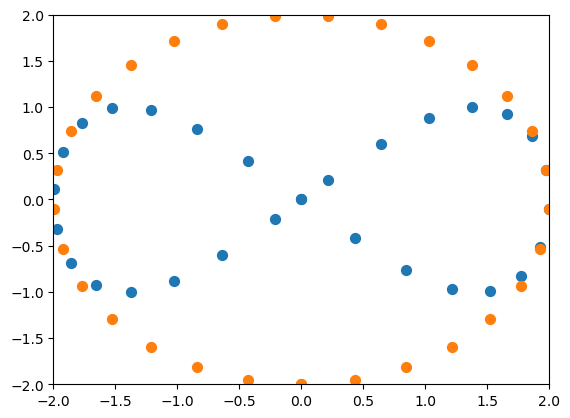

In [22]:
# inf-trajectory
import numpy as np
import matplotlib.pyplot as plt

NB_POINTS = 30
SCALE = 2
Z_HEIGHT = 0.5
t = np.linspace(-np.pi/2, 3*np.pi/2, NB_POINTS)
TRAJECTORY_INF_LOOP = np.array([SCALE*np.cos(t), SCALE*np.sin(2*t)/2, Z_HEIGHT*np.ones(NB_POINTS)]).T
TRAJECTORY_CRICLE = np.array([SCALE*np.cos(t), SCALE*np.sin(t), Z_HEIGHT*np.ones(NB_POINTS)]).T

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(TRAJECTORY_INF_LOOP[:,0], TRAJECTORY_INF_LOOP[:,1], s=50)
ax.scatter(TRAJECTORY_CRICLE[:,0], TRAJECTORY_CRICLE[:,1], s=50)
ax.set_xlim([-2,2])
ax.set_ylim([-2,2])